<a href="https://colab.research.google.com/github/ssprajapati2021/Hybrid-RAG-Fine-Tuning/blob/main/notebook/Data_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 2: Data Preparation**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `sampled_data.csv` — Created by Notebook 1
- [ ] `corporate_policies/` folder with `.md` SOP files
- [ ] Internet access (to download the tokenizer)

**Files this notebook will CREATE:**
- [ ] `./tokenized_train/`, `./tokenized_valid/`, `./tokenized_test/` — HuggingFace datasets _(Required by NB6)_
- [ ] `df_test.csv` — Test set with readable text + labels _(Required by NB5 and NB7)_

---

In [1]:
# Mount Google Drive to access the corporate_policies Markdown (.md) files with sampled_data.csv
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## **Stage 2: Data Preparation**
### **Task 2.1: Clean and Validate Dataset**

#### **2.1.1 Remove Duplicate and Invalid Records [2 marks]**
**The Task:** Identify and remove duplicate records using normalised deduplication (lowercase + strip before comparison), plus any invalid, incomplete, or corrupted records.

**Hints & Tips:**
* Load `sampled_data.csv` from Notebook 1 first.
* Normalised dedup: create a temporary `_norm` column = `instruction.str.lower().str.strip()`, drop duplicates on it, then drop the helper column.
* Check for nulls in `instruction`, `intent`, and `category` — drop rows missing any of these targets.
* Print the number of rows removed so the cleaning is auditable.

**Why we are doing it:** To prevent degraded training from redundant or broken records, and to stop near-duplicates leaking across train/test splits later.
**How we are doing it:** Pandas normalised deduplication and null filtering.

**Learner Inference:** Exact-match dedup misses `"Where is my order?"` vs `"where is my order?"`. Normalising first catches these and keeps your splits clean.

In [2]:
# Loading Sampled_data.csv
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/corporate_policies/sampled_data.csv")

print(f"Shape of Dataframe: {df.shape}")
print(f"\n First Five Values: \n{ df.head(5)}")

Shape of Dataframe: (3902, 5)

 First Five Values: 
   flags                                        instruction category  \
0    BLZ                   I can't talk with  a human agent  CONTACT   
1   BLMZ  I have got to locate hte bills from {{Person N...  INVOICE   
2  BCELM  I cannot pay, help me to inform of a problem w...  PAYMENT   
3     BL           I want help speaking to customer service  CONTACT   
4    BLZ           I try to see th accepted payment options  PAYMENT   

                     intent                                           response  
0       contact_human_agent  Thank you for reaching out! I'm sorry to hear ...  
1             check_invoice  I'll get right on it! I understand your need t...  
2             payment_issue  I apologize for the inconvenience caused by th...  
3  contact_customer_service  Grateful for your contact! I get the sense tha...  
4     check_payment_methods  Thank you for reaching out! I completely under...  


In [3]:
rows_before = len(df)

# Normalized instruction
df["_norm"] = df["instruction"].str.lower().str.strip()

duplicate_count = df.duplicated(subset="_norm").sum()

df = df.drop_duplicates(subset="_norm")

# Remove invalid records
df = df.dropna(subset=["instruction", "intent", "category"])

rows_after = len(df)

print(f"Rows before cleaning : {rows_before}")
print(f"Duplicate rows found : {duplicate_count}")
print(f"Rows removed         : {rows_before - rows_after}")
print(f"Rows after cleaning  : {rows_after}")

df.drop(columns="_norm", inplace=True)

# Check missing values
print(f"\n Check for missing values:\n {df[["instruction", "intent", "category"]].isnull().sum()}")
# Remove invalid rows
df = df.dropna(subset=["instruction", "intent", "category"])

print(f"Final Shape of dataset: {df.shape}")

Rows before cleaning : 3902
Duplicate rows found : 0
Rows removed         : 0
Rows after cleaning  : 3902

 Check for missing values:
 instruction    0
intent         0
category       0
dtype: int64
Final Shape of dataset: (3902, 5)


#### **2.1.2 Standardise Dataset Formatting [2 marks]**
**The Task:** Clean the strings inside `instruction`, `intent`, and `category` by stripping whitespace and enforcing uniform casing (intents = lower, categories = upper).

**Hints & Tips:**
* Use Pandas `.str.strip()`, `.str.lower()`, `.str.upper()`.
* Always strip whitespace BEFORE lowering — trailing spaces survive `.lower()`.
* Standardised casing prevents the model treating "Refund" and "refund" as different classes.

**Why we are doing it:** To ensure raw strings are perfectly standardised before injecting them into prompt templates.
**How we are doing it:** Pandas string manipulation.

**Learner Inference:** Standardising capitalisation prevents the model from treating the same intent written two ways as two separate classes.

In [4]:
# Remove leading/trailing whitespace
df["instruction"] = df["instruction"].str.strip()

# Standardize intent to lowercase
df["intent"] = df["intent"].str.strip().str.lower()

# Standardize category to uppercase
df["category"] = df["category"].str.strip().str.upper()

# Verifying the results
display(df[["instruction", "intent", "category"]].head())


,instruction,intent,category
0,I can't talk with a human agent,contact_human_agent,CONTACT
1,I have got to locate hte bills from {{Person N...,check_invoice,INVOICE
2,"I cannot pay, help me to inform of a problem w...",payment_issue,PAYMENT
3,I want help speaking to customer service,contact_customer_service,CONTACT
4,I try to see th accepted payment options,check_payment_methods,PAYMENT


### **Task 2.2: Create Instruction-Tuning Dataset**

#### **2.2.1 Transform Records into Instruction Format [2 marks]**
**The Task:** Wrap the raw instructions and targets into a standardized `ChatML` format, forcing the assistant's response to be a strict JSON string containing the `intent` and `category`.

**Hints & Tips:**
* Use the Qwen tokenizer's `apply_chat_template(tokenize=False)`.
* The target JSON is `{"intent": "...", "category": "..."}` — built via `json.dumps()`.

**Model Selection:**
* **Qwen/Qwen2.5-1.5B-Instruct** (recommended) — fits T4, strong instruction following.
* **TinyLlama-1.1B-Chat** — lighter but weaker at structured output.
* **Llama-3-8B-Instruct** — best quality, needs >16GB VRAM even in 4-bit.
* Whatever you pick, set `MODEL_ID` here and in ALL later notebooks.

**Learner Inference:** Formatting the target as JSON establishes the exact structural rules the LoRA model learns to mimic in Stage 4.

In [5]:
from transformers import AutoTokenizer
import json

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [6]:
def format_dataset(row):
    messages = [
        {
            "role": "system",
            "content": (
                "You are an AI assistant that classifies customer support requests. "
                "Return ONLY valid JSON."
            ),
        },
        {
            "role": "user",
            "content": row["instruction"],
        },
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    target = json.dumps(
        {
            "intent": row["intent"],
            "category": row["category"],
        }
    )

    return pd.Series(
        {
            "prompt": prompt,
            "response": target,
        }
    )

In [7]:
# Add new columns to the existing DataFrame
df[["prompt", "response"]] = df.apply(format_dataset, axis=1)

# Verifying the dataset
print(f"Verifying Prompt: \n {df["prompt"].iloc[0]}")

print(f"Verifying response: \n {df["response"].iloc[0]}")

Verifying Prompt: 
 <|im_start|>system
You are an AI assistant that classifies customer support requests. Return ONLY valid JSON.<|im_end|>
<|im_start|>user
I can't talk with  a human agent<|im_end|>
<|im_start|>assistant

Verifying response: 
 {"intent": "contact_human_agent", "category": "CONTACT"}


#### **2.2.2 Validate Instruction Templates [2 marks]**
**The Task:** Extract the assistant's portion of the generated ChatML string and parse it with `json.loads()` to verify structural integrity.

**Hints & Tips:**
* Split the string by `<|im_start|>assistant` and parse what follows.
* If this throws `JSONDecodeError`, your formatting in 2.2.1 is broken — fix before training.
* Validate several samples, not just the first.

**Learner Inference:** A JSONDecodeError here means the model would learn broken syntax. Catching it now saves a failed training run.

In [8]:
# Creating a Validation Function with ChatML
def create_chatml(row):
    messages = [
        {
            "role": "system",
            "content": (
                "You are an AI assistant that classifies customer support requests. "
                "Return ONLY valid JSON."
            ),
        },
        {
            "role": "user",
            "content": row["instruction"],
        },
        {
            "role": "assistant",
            "content": json.dumps(
                {
                    "intent": row["intent"],
                    "category": row["category"],
                }
            ),
        },
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False
    )

In [9]:
df["chatml"] = df.apply(create_chatml, axis=1)

In [10]:
# Parsing with json.loads() and validating 5 samples
for i in range(5):
    print(f"\nValidating Sample {i+1}")

    try:
        assistant_text = (
            df.loc[i, "chatml"]
            .split("<|im_start|>assistant")[1]
            .split("<|im_end|>")[0]
            .strip()
        )

        parsed = json.loads(assistant_text)

        print("✅ Valid JSON")
        print(parsed)

    except json.JSONDecodeError as e:
        print("❌ Invalid JSON")
        print(e)


Validating Sample 1
✅ Valid JSON
{'intent': 'contact_human_agent', 'category': 'CONTACT'}

Validating Sample 2
✅ Valid JSON
{'intent': 'check_invoice', 'category': 'INVOICE'}

Validating Sample 3
✅ Valid JSON
{'intent': 'payment_issue', 'category': 'PAYMENT'}

Validating Sample 4
✅ Valid JSON
{'intent': 'contact_customer_service', 'category': 'CONTACT'}

Validating Sample 5
✅ Valid JSON
{'intent': 'check_payment_methods', 'category': 'PAYMENT'}


### **Task 2.3: Engineer Training and Retrieval Data**

#### **2.3.1 Tokenise Dataset [2 marks]**
**The Task:** Convert text sequences into tensor IDs and apply `-100` masking to padding tokens in the `labels` array.

**Hints & Tips:**
* If a token equals `tokenizer.pad_token_id`, replace it with `-100` in labels.
* `-100` is PyTorch's ignore index — the loss skips these tokens.

**Parameter Tuning:**
* `max_length`: `128` (fast, fits most Bitext prompts), `256` (safer if truncation seen), `64` (too aggressive).

**Learner Inference:** Masking isolates the loss — the model is penalised for wrong JSON, not for padding.

In [11]:
# Converting the Pandas DataFrame to a Hugging Face Dataset to apply the tokenizer to all records using the .map() method and
# simplifying the preprocessing workflow.
from datasets import Dataset

hf_dataset = Dataset.from_pandas(df)
print(hf_dataset)

Dataset({
    features: ['flags', 'instruction', 'category', 'intent', 'response', 'prompt', 'chatml'],
    num_rows: 3902
})


In [12]:
# Define Tokenizer Function as per our requiremt described in markdown
def tokenize_function(dataset):
    # Combine prompt and target response
    full_text = dataset["prompt"] + dataset["response"]

    encoding = tokenizer(
        full_text,
        truncation=True,
        padding="max_length",
        max_length=128,
    )

    labels = encoding["input_ids"].copy()

    # Mask padding tokens
    labels = [
        token if token != tokenizer.pad_token_id else -100
        for token in labels
    ]

    encoding["labels"] = labels

    return encoding

In [13]:
# apply tokenization
tokenized_dataset = hf_dataset.map(tokenize_function)

# Verify the output
print(tokenized_dataset[0].keys())

Map:   0%|          | 0/3902 [00:00<?, ? examples/s]

dict_keys(['flags', 'instruction', 'category', 'intent', 'response', 'prompt', 'chatml', 'input_ids', 'attention_mask', 'labels'])


In [14]:
#Inspecting Tokenized Data
print(f"Input IDs:\n {tokenized_dataset[0]["input_ids"]}")

print(f"\nAttention Mask:\n {tokenized_dataset[0]["attention_mask"]}")

print(f"\nLabels:\n {tokenized_dataset[0]["labels"]}")

Input IDs:
 [151644, 8948, 198, 2610, 525, 458, 15235, 17847, 429, 536, 9606, 6002, 1824, 7388, 13, 3411, 26687, 2697, 4718, 13, 151645, 198, 151644, 872, 198, 40, 646, 944, 3061, 448, 220, 264, 3738, 8315, 151645, 198, 151644, 77091, 198, 4913, 56431, 788, 330, 6287, 86247, 25730, 497, 330, 5471, 788, 330, 73371, 9207, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643]

Attention Mask:
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

#### **2.3.2 Analyse Token Distributions [2 marks]**
**The Task:** Analyse the token-count distribution to detect truncation risks and verify the sequence-length configuration.

**Hints & Tips:**
* Count non-padding tokens per row and plot a histogram.
* If >5% of rows hit `max_length`, increase it.
* The JSON target is ~20 tokens — if truncated, the model learns incomplete output.

**Learner Inference:** Sequences hitting the ceiling mean the JSON target is getting cut off, teaching the model to produce broken output.

In [23]:
# YOUR CODE HERE
token_counts = []

for _dataset in tokenized_dataset:
    token_counts.append(sum(_dataset["attention_mask"]))

print(token_counts)


[53, 57, 57, 51, 53, 54, 61, 50, 57, 62, 53, 58, 56, 56, 53, 57, 55, 56, 51, 52, 54, 56, 60, 53, 56, 54, 56, 54, 54, 59, 53, 49, 62, 60, 58, 50, 51, 53, 54, 52, 52, 55, 55, 61, 53, 54, 53, 58, 53, 47, 52, 52, 57, 56, 54, 60, 54, 51, 58, 56, 58, 53, 55, 52, 53, 63, 57, 52, 58, 54, 55, 56, 51, 56, 59, 52, 51, 54, 55, 53, 51, 56, 66, 56, 52, 58, 56, 53, 57, 52, 52, 52, 51, 55, 58, 54, 53, 53, 54, 51, 56, 53, 51, 56, 56, 57, 58, 55, 56, 58, 51, 53, 58, 51, 55, 56, 53, 54, 58, 56, 55, 57, 52, 52, 51, 49, 54, 64, 51, 54, 54, 53, 55, 53, 51, 56, 53, 59, 53, 55, 59, 56, 58, 59, 50, 56, 53, 48, 49, 57, 52, 49, 52, 53, 53, 57, 60, 57, 55, 56, 53, 56, 60, 53, 55, 53, 49, 51, 55, 52, 56, 56, 48, 50, 55, 51, 59, 50, 54, 52, 53, 54, 50, 59, 55, 52, 49, 51, 55, 53, 53, 55, 53, 51, 54, 52, 58, 52, 53, 55, 55, 55, 54, 54, 56, 53, 56, 60, 57, 52, 50, 55, 56, 59, 51, 55, 53, 52, 53, 57, 51, 50, 55, 48, 58, 58, 52, 57, 53, 56, 52, 52, 55, 52, 57, 54, 56, 55, 48, 56, 57, 56, 59, 61, 54, 53, 58, 51, 53, 48,

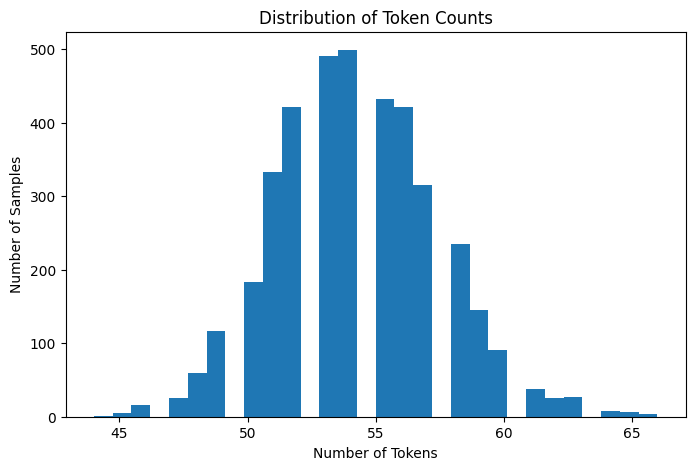

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(token_counts, bins=30)

plt.xlabel("Number of Tokens")
plt.ylabel("Number of Samples")
plt.title("Distribution of Token Counts")

plt.show()

In [26]:
max_length = 128

truncated = sum(
    count >= max_length
    for count in token_counts
)

percentage = (truncated / len(token_counts)) * 100

print(f"Sequences at max length: {truncated}")
print(f"Percentage: {percentage:.2f}%")

if percentage > 5:
    print("More than 5% of sequences reached the maximum length.")
    print("Consider increasing max_length to 256.")
else:
    print("✅ Current max_length is sufficient.")

Sequences at max length: 0
Percentage: 0.00%
✅ Current max_length is sufficient.


#### **2.3.3 Prepare Retrieval Corpus [3 marks]**
**The Task:** Ingest the Markdown SOPs into LangChain Document objects ready to be embedded.

**Hints & Tips:**
* Use `TextLoader` from LangChain.
* Each `.md` file becomes one `Document` with `.page_content` and `.metadata`.
* These documents are embedded into ChromaDB in Notebook 4.

**Learner Inference:** These document objects form the knowledge base your bot retrieves from in Stages 3 and 4.

In [28]:
# Missing installation
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [30]:
import glob
from langchain_community.document_loaders import TextLoader
md_files = glob.glob("/content/drive/MyDrive/corporate_policies/sop_documents/*.md")

print(f"Total SOP files found: {len(md_files)}")

documents = []

for file in md_files:
    loader = TextLoader(file, encoding="utf-8")
    documents.extend(loader.load())

print(f"Total Documents Loaded: {len(documents)}")

Total SOP files found: 13
Total Documents Loaded: 13


In [35]:
# Verifying the document, metadata and its contents
print(documents)

print(f"\nType of Document: {type(documents[0])}")

print(f"\nMetadata:\n {documents[0].metadata}")

print(f"\nContent:\n {documents[0].page_content[:500]}")

[Document(metadata={'source': '/content/drive/MyDrive/corporate_policies/sop_documents/refund_policy.md'}, page_content="# Refund Policy\n\n## Eligibility\nCustomers may request a refund within 30 days of the original purchase or\ndelivery date, whichever is later. To be eligible, the item must be unused or\ndefective, and the request must reference a valid order identifier. Digital\ngoods and subscription fees already consumed are non-refundable except where\nrequired by local consumer law.\n\n## Refund Methods\nApproved refunds are issued to the original payment method. If the original\ncard or wallet is no longer active, store credit of equal value is offered as\nan alternative. Cash refunds are not provided for online orders.\n\n## Processing Time\nOnce a refund is approved, the amount is released within 5–7 business days.\nBank or card-network posting can add a further 3–5 business days, so advise\ncustomers that the full cycle may take up to 12 business days. Duplicate or\naccide

### **Task 2.4: Create Dataset Partitions**

#### **2.4.1 Create Train, Validation, and Test Splits [5 marks]**
**The Task:** Split the tokenized dataset into Train (80%), Validation (10%), and Test (10%) partitions using stratified sampling. Demonstrate zero data leakage across all three.

**Hints & Tips:**
* Use `train_test_split` from sklearn with `stratify=df['intent']` so every intent appears in all splits.
* Split twice: first 80/20, then split the 20% into 50/50 (giving 10%/10%).
* The validation set is not optional — it is actively used during fine-tuning (Stage 4 / Notebook 6) for loss monitoring and early stopping.
* The test set must stay completely independent — used only for final evaluation.
* Verify zero overlap with set-intersection checks: `assert len(train_set & test_set) == 0`.
* Build a `df_test` DataFrame preserving readable `text`/`intent`/`category` columns for later scoring.

**Parameter Tuning:**
* Split ratio: `80/10/10` (recommended) or `70/15/15`. Any alternative must be justified.

**Why we are doing it:** To guarantee isolated, unseen data for unbiased evaluation, and a validation set for overfitting detection.
**How we are doing it:** Stratified sklearn splits with explicit programmatic leakage verification.

**Learner Inference:** Testing on data the model trained on gives false confidence (leakage). The held-out test split proves your model handles completely new phrasing; the validation split tells you when to stop training.

In [37]:
from sklearn.model_selection import train_test_split

# First Split (80% & 20%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["intent"],
    random_state=42
)

# Split 20% temp_df into 50% & 50%

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["intent"],
    random_state=42
)

# Verifying the split sizes

print(f"Train samples      : {len(train_df)}")
print(f"Validatio samples  : {len(val_df)}")
print(f"Test samples       : {len(test_df)}")

Train samples      : 3121
Validatio samples  : 390
Test samples       : 391


In [38]:
# Verifying Class Distribution

print(f"Train : {train_df["intent"].value_counts()}")
print(f"\nValidation : {val_df["intent"].value_counts()}")
print(f"\nTest : {test_df["intent"].value_counts()}")

Train : intent
review                      133
get_invoice                 132
create_account              130
set_up_shipping_address     127
contact_customer_service    126
payment_issue               126
check_payment_methods       126
contact_human_agent         124
complaint                   122
change_shipping_address     122
registration_problems       122
delivery_options            121
check_refund_policy         118
check_invoice               117
place_order                 115
track_refund                115
recover_password            114
check_cancellation_fee      114
delivery_period             111
track_order                 108
get_refund                  108
edit_account                107
delete_account              104
change_order                102
switch_account               99
newsletter_subscription      92
cancel_order                 86
Name: count, dtype: int64

Validation : intent
create_account              16
contact_customer_service    16
review      

In [39]:
#Verifying Zero data leakage
train_set = set(train_df["instruction"])
val_set = set(val_df["instruction"])
test_set = set(test_df["instruction"])

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("✅ Zero data leakage detected.")

✅ Zero data leakage detected.


In [40]:
# Build the test dataframe df_test
df_test = test_df[
    [
        "instruction",
        "intent",
        "category"
    ]
].copy()

df_test.head()

,instruction,intent,category
193,need help to shop several of ur item,place_order,ORDER
2240,i need assistance trying to update the shippin...,change_shipping_address,SHIPPING
2947,I do not know how to check the cancellation p...,check_cancellation_fee,CANCEL
192,want assistance to see the payment modalities,check_payment_methods,PAYMENT
3536,how can I get information about opening a stan...,create_account,ACCOUNT


---
## Save Artifacts for Downstream Notebooks

**IMPORTANT:** These cells save all datasets. Notebooks 5, 6, and 7 depend on them.

In [18]:
# YOUR CODE HERE


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 3.**

- [ ] `sampled_data.csv` loaded
- [ ] **Duplicates + invalid records removed (normalised dedup)** ← _Task 2.1.1_
- [ ] Data standardised (intent=lower, category=UPPER)
- [ ] ChatML formatting applied and validated (valid JSON)
- [ ] Tokenization completed with `-100` label masking
- [ ] Token distribution analysed — truncation risk assessed
- [ ] Retrieval corpus loaded from `.md` files
- [ ] **Stratified Train/Valid/Test split** with all intents in every partition
- [ ] **Zero leakage verified** via set-intersection checks
- [ ] **`./tokenized_train/` + `./tokenized_valid/` saved** ← _CRITICAL for NB6_
- [ ] **`df_test.csv` saved** ← _CRITICAL for NB5 and NB7_

**If any item is unchecked, fix it before moving on.**